# CSL7110 Assignment 3  
## Recommender Systems: Content-Based and Collaborative Filtering

**Name:** Ashish Sinha  
**Roll No:** M25DE1047

## Setup and Imports

In [1]:
# Install required packages
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import math
import random
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import DoubleType, ArrayType, FloatType
from pyspark.storagelevel import StorageLevel

from pyspark.ml import Pipeline
from pyspark.ml.feature import HashingTF, IDF
from pyspark.ml.linalg import DenseVector, SparseVector, VectorUDT
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

import shap

import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

/Users/ashishsinha/Documents/Study/MTech/Sm02/MLwDE/Assignment03/gihubrepo/iitj_m25de1047_mlbd_Assignment03/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Spark Session Configuration

In [3]:
spark = (
    SparkSession.builder
    .appName("CSL7110_Assignment3")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.default.parallelism", "64")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/19 01:19:32 WARN Utils: Your hostname, ASHISHs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.6 instead (on interface en0)
26/03/19 01:19:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/19 01:19:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


## Dataset Configuration

In [4]:
project_root = Path.cwd().resolve().parent
BASE_DIR = project_root / "dataset" / "ml-latest-small"
MOVIES_FILE  = f"file://{(BASE_DIR / 'movies.csv').resolve()}"
RATINGS_FILE = f"file://{(BASE_DIR / 'ratings.csv').resolve()}"

TOP_K             = 5
POSITIVE_THRESHOLD = 4.0

# Memory-safety knobs (adjust as per current system or other may have more RAM other system)
MAX_EVAL_USERS   = 100
MAX_CF_USERS     = 800
MAX_CF_MOVIES    = 1200
MAX_LOCAL_MOVIES = 5000
MAX_LOCAL_RATINGS = 150000
MAX_NEURAL_ROWS  = 80000

print("Movies path :", MOVIES_FILE)
print("Ratings path:", RATINGS_FILE)

Movies path : file:///Users/ashishsinha/Documents/Study/MTech/Sm02/MLwDE/Assignment03/gihubrepo/iitj_m25de1047_mlbd_Assignment03/dataset/ml-latest-small/movies.csv
Ratings path: file:///Users/ashishsinha/Documents/Study/MTech/Sm02/MLwDE/Assignment03/gihubrepo/iitj_m25de1047_mlbd_Assignment03/dataset/ml-latest-small/ratings.csv


## Load Dataset with Spark

In [5]:
movies_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(MOVIES_FILE)
)

ratings_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(RATINGS_FILE)
)

print("Movies rows :", movies_raw.count())
print("Ratings rows:", ratings_raw.count())

movies_raw.show(5, truncate=False)
ratings_raw.show(5, truncate=False)

Movies rows : 9742
Ratings rows: 100836
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Comedy                                     |
+-------+----------------------------------+-------------------------------------------+
only showing top 5 rows
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|

## Preprocessing

In [6]:
# ── Clean genres and extract release year from title ──────────────────────────
movies = (
    movies_raw
    .withColumn(
        "genres_clean",
        F.when(
            F.col("genres").isNull() | (F.col("genres") == "(no genres listed)"),
            F.lit("Unknown")
        ).otherwise(F.col("genres"))
    )
    .withColumn(
        "year",
        F.when(
            F.col("title").rlike(r"\((\d{4})\)\s*$"),
            F.regexp_extract(F.col("title"), r"\((\d{4})\)\s*$", 1).cast("int")
        ).otherwise(F.lit(None).cast("int"))
    )
)

# ── Per-movie and per-user aggregate statistics ────────────────────────────────
movie_stats = (
    ratings_raw
    .groupBy("movieId")
    .agg(
        F.count("*").alias("movie_rating_count"),
        F.avg("rating").alias("movie_avg_rating")
    )
)

user_stats = (
    ratings_raw
    .groupBy("userId")
    .agg(
        F.count("*").alias("user_rating_count"),
        F.avg("rating").alias("user_avg_rating")
    )
)

global_mean_rating = ratings_raw.agg(F.avg("rating").alias("avg")).first()["avg"]

movies = (
    movies.join(movie_stats, on="movieId", how="left")
    .fillna({
        "movie_rating_count": 0,
        "movie_avg_rating": float(global_mean_rating)
    })
)

movies.persist(StorageLevel.MEMORY_AND_DISK)
user_stats.persist(StorageLevel.MEMORY_AND_DISK)

movies.show(5, truncate=False)

+-------+----------------------------------+-------------------------------------------+-------------------------------------------+----+------------------+------------------+
|movieId|title                             |genres                                     |genres_clean                               |year|movie_rating_count|movie_avg_rating  |
+-------+----------------------------------+-------------------------------------------+-------------------------------------------+----+------------------+------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|Adventure|Animation|Children|Comedy|Fantasy|1995|215               |3.9209302325581397|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |Adventure|Children|Fantasy                 |1995|110               |3.4318181818181817|
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |Comedy|Romance                  

In [7]:
# ── split; to ensure test users and movies exist in train ────────────
train_ratings, test_ratings = ratings_raw.randomSplit([0.8, 0.2], seed=42)

train_users  = train_ratings.select("userId").distinct()
train_movies = train_ratings.select("movieId").distinct()

test_ratings_in_train = (
    test_ratings
    .join(train_users,  on="userId",  how="inner")
    .join(train_movies, on="movieId", how="inner")
)

print("Train ratings         :", train_ratings.count())
print("Test ratings          :", test_ratings.count())
print("Filtered test ratings :", test_ratings_in_train.count())

Train ratings         : 80578
Test ratings          : 20258
Filtered test ratings : 19437


## Common Helper Functions

In [8]:
def precision_recall_at_k(recommended_ids, relevant_ids, k=5):
    """Compute Precision@K and Recall@K given ranked recommendation list."""
    recommended_top_k = list(recommended_ids)[:k]
    relevant_set = set(relevant_ids)
    hits = len(set(recommended_top_k) & relevant_set)
    precision = hits / k if k > 0 else 0.0
    recall    = hits / len(relevant_set) if len(relevant_set) > 0 else 0.0
    return precision, recall


def rmse_score(y_true, y_pred):
    """Root Mean Squared Error between two lists."""
    if len(y_true) == 0:
        return float("nan")
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def clip_rating(x, low=0.5, high=5.0):
    return float(np.clip(x, low, high))


def to_numpy(v):
    """Convert a Spark ML Vector (sparse or dense) to a NumPy array."""
    if isinstance(v, SparseVector):
        return v.toArray()
    if isinstance(v, DenseVector):
        return np.array(v)
    return np.array(v)

In [9]:
# ── Pre-compute seen movies and ground-truth relevant movies for eval users ────
train_seen_movies_pd = (
    train_ratings.groupBy("userId")
    .agg(F.collect_set("movieId").alias("seen_movies"))
    .toPandas()
)
train_seen_movies = dict(zip(
    train_seen_movies_pd["userId"],
    train_seen_movies_pd["seen_movies"]
))

relevant_test_pd = (
    test_ratings_in_train
    .filter(F.col("rating") >= POSITIVE_THRESHOLD)
    .groupBy("userId")
    .agg(F.collect_list("movieId").alias("relevant_movies"))
    .orderBy(F.desc(F.size("relevant_movies")))
    .limit(MAX_EVAL_USERS)
    .toPandas()
)
relevant_test_items = dict(zip(
    relevant_test_pd["userId"],
    relevant_test_pd["relevant_movies"]
))
eval_users = list(relevant_test_items.keys())

print(f"Evaluation users: {len(eval_users)}")

Evaluation users: 100


---
# Part 1: Content-Based Filtering

## Task 1: TF-IDF Based Recommendation Using Movie Genres

In [10]:
# ── Build PySpark TF-IDF pipeline on genre tokens ─────────────────────────────
movies_tokens = movies.withColumn(
    "genre_tokens", F.split(F.col("genres_clean"), r"\|")
)

hashing_tf  = HashingTF(inputCol="genre_tokens", outputCol="raw_features", numFeatures=1024)
idf         = IDF(inputCol="raw_features", outputCol="tfidf_features")
tfidf_pipeline = Pipeline(stages=[hashing_tf, idf])
tfidf_model    = tfidf_pipeline.fit(movies_tokens)

movies_tfidf = tfidf_model.transform(movies_tokens).select(
    "movieId", "title", "genres_clean", "year",
    "movie_rating_count", "movie_avg_rating", "tfidf_features"
)

movies_tfidf.persist(StorageLevel.MEMORY_AND_DISK)
print("TF-IDF pipeline fitted and applied.")
movies_tfidf.show(5, truncate=False)

TF-IDF pipeline fitted and applied.
+-------+----------------------------------+-------------------------------------------+----+------------------+------------------+----------------------------------------------------------------------------------------------------------------------------+
|movieId|title                             |genres_clean                               |year|movie_rating_count|movie_avg_rating  |tfidf_features                                                                                                              |
+-------+----------------------------------+-------------------------------------------+----+------------------+------------------+----------------------------------------------------------------------------------------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|1995|215               |3.9209302325581397|(1024,[102,356,644,819,950],[2.7675720749130153,2.525010437741

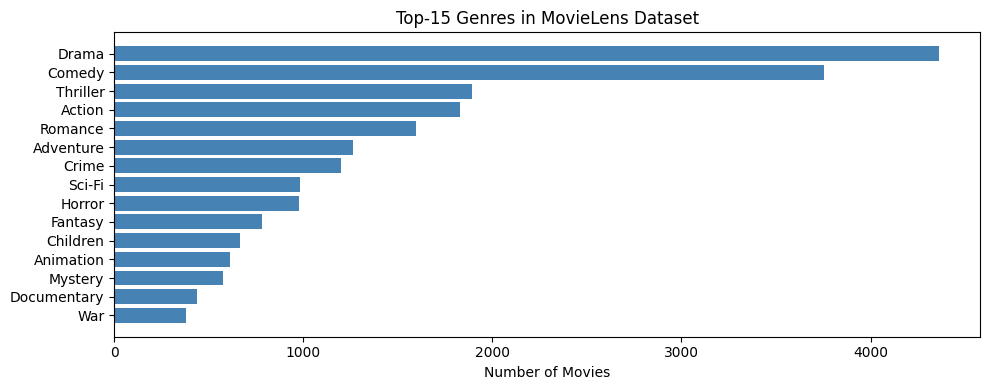

In [11]:
# ── Visualisation: Top-15 genres by movie count ───────────────────────────────
genre_counts = (
    movies.withColumn("genre", F.explode(F.split("genres_clean", r"\|")))
    .groupBy("genre").count()
    .orderBy(F.desc("count"))
    .limit(15)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(genre_counts["genre"][::-1], genre_counts["count"][::-1], color="steelblue")
ax.set_xlabel("Number of Movies")
ax.set_title("Top-15 Genres in MovieLens Dataset")
plt.tight_layout()
plt.show()

In [12]:
# ── Collect top-N popular movies locally for similarity computation ────────────
popular_movie_ids = [
    r["movieId"]
    for r in movies_tfidf.orderBy(F.desc("movie_rating_count"))
              .select("movieId").limit(MAX_LOCAL_MOVIES).collect()
]

movies_tfidf_local = (
    movies_tfidf
    .filter(F.col("movieId").isin(popular_movie_ids))
    .select("movieId", "title", "genres_clean", "year", "tfidf_features")
    .toPandas()
)

movies_tfidf_local["tfidf_np"] = movies_tfidf_local["tfidf_features"].apply(to_numpy)
movie_id_to_vec = dict(zip(movies_tfidf_local["movieId"], movies_tfidf_local["tfidf_np"]))


def cosine_np(a, b):
    """Fast cosine similarity between two NumPy vectors."""
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0


def recommend_similar_movies(movie_query, top_n=5):
    """
    Return the top-N movies most similar to `movie_query` (title substring or movieId)
    using TF-IDF cosine similarity on genres.
    """
    if isinstance(movie_query, str):
        matched = movies_tfidf_local[
            movies_tfidf_local["title"].str.contains(movie_query, case=False, na=False)
        ]
        if matched.empty:
            raise ValueError(f"No title matched: {movie_query}")
        target = matched.iloc[0]
    else:
        matched = movies_tfidf_local[movies_tfidf_local["movieId"] == int(movie_query)]
        if matched.empty:
            raise ValueError(f"movieId not found: {movie_query}")
        target = matched.iloc[0]

    rows = [
        (row.movieId, row.title, row.genres_clean, row.year,
         cosine_np(target["tfidf_np"], row.tfidf_np))
        for row in movies_tfidf_local.itertuples(index=False)
        if row.movieId != target["movieId"]
    ]
    out = pd.DataFrame(rows, columns=["movieId","title","genres_clean","year","similarity_score"])
    return out.sort_values("similarity_score", ascending=False).head(top_n).reset_index(drop=True)


# ── Test with sample queries ───────────────────────────────────────────────────
for query in ["Toy Story", "Matrix", "Fargo"]:
    print(f"\n=== Recommendations for: '{query}' ===")
    display(recommend_similar_movies(query, top_n=5))


=== Recommendations for: 'Toy Story' ===


,movieId,title,genres_clean,year,similarity_score
0,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,2000.0,1.0
1,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,2007.0,1.0
2,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,2001.0,1.0
3,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,2000.0,1.0
4,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1999.0,1.0



=== Recommendations for: 'Matrix' ===


,movieId,title,genres_clean,year,similarity_score
0,2600,eXistenZ (1999),Action|Sci-Fi|Thriller,1999.0,1.0
1,692,Solo (1996),Action|Sci-Fi|Thriller,1996.0,1.0
2,1882,Godzilla (1998),Action|Sci-Fi|Thriller,1998.0,1.0
3,79057,Predators (2010),Action|Sci-Fi|Thriller,2010.0,1.0
4,5903,Equilibrium (2002),Action|Sci-Fi|Thriller,2002.0,1.0



=== Recommendations for: 'Fargo' ===


,movieId,title,genres_clean,year,similarity_score
0,71211,"Informant!, The (2009)",Comedy|Crime|Drama|Thriller,2009.0,1.0
1,88129,Drive (2011),Crime|Drama|Film-Noir|Thriller,2011.0,1.0
2,3728,One False Move (1992),Crime|Drama|Film-Noir|Thriller,1992.0,1.0
3,1034,Freeway (1996),Comedy|Crime|Drama|Thriller,1996.0,1.0
4,7216,High Sierra (1941),Crime|Drama|Film-Noir|Thriller,1941.0,1.0


## Task 2: User-Profile-Based Content Recommender

In [13]:
# ── Spark join: attach TF-IDF vector to every training rating ─────────────────
train_with_tfidf = (
    train_ratings
    .join(movies_tfidf.select("movieId", "tfidf_features"), on="movieId", how="inner")
    .join(user_stats.select("userId", "user_rating_count"),  on="userId",  how="inner")
    .filter(F.col("user_rating_count") >= 20)
    .limit(MAX_LOCAL_RATINGS)
)

# ── Aggregate weighted profile vectors locally ─────────────────────────────────
user_profile_dict = defaultdict(lambda: {"weighted_sum": None, "rating_sum": 0.0})

for row in train_with_tfidf.select("userId", "rating", "tfidf_features").toLocalIterator():
    vec = to_numpy(row["tfidf_features"])
    uid, r = row["userId"], float(row["rating"])
    if user_profile_dict[uid]["weighted_sum"] is None:
        user_profile_dict[uid]["weighted_sum"] = vec * r
    else:
        user_profile_dict[uid]["weighted_sum"] += vec * r
    user_profile_dict[uid]["rating_sum"] += r

# ── Normalise each profile vector to unit length ──────────────────────────────
user_profiles = {}
for uid, payload in user_profile_dict.items():
    profile = payload["weighted_sum"] / max(payload["rating_sum"], 1e-9)
    norm = np.linalg.norm(profile)
    user_profiles[uid] = profile / norm if norm > 0 else profile

print(f"User profiles created: {len(user_profiles)}")

User profiles created: 610


In [14]:
def recommend_content_for_user(user_id, top_n=5):
    """
    Recommend top-N unseen movies for a user by cosine similarity
    between their weighted TF-IDF profile and all movie vectors.
    """
    if user_id not in user_profiles:
        return pd.DataFrame(columns=["movieId","title","content_score"])

    seen     = set(train_seen_movies.get(user_id, []))
    user_vec = user_profiles[user_id]

    rows = [
        (row.movieId, row.title, row.genres_clean, row.year,
         cosine_np(user_vec, row.tfidf_np))
        for row in movies_tfidf_local.itertuples(index=False)
        if row.movieId not in seen
    ]
    out = pd.DataFrame(rows, columns=["movieId","title","genres_clean","year","content_score"])
    return out.sort_values("content_score", ascending=False).head(top_n).reset_index(drop=True)


# ── Evaluate Precision@K and Recall@K ────────────────────────────────────────
content_eval_rows = []
for uid in eval_users:
    if uid not in user_profiles:
        continue
    rec_df      = recommend_content_for_user(uid, TOP_K)
    rec_ids     = rec_df["movieId"].tolist()
    relevant_ids = relevant_test_items.get(uid, [])
    p5, r5      = precision_recall_at_k(rec_ids, relevant_ids, TOP_K)
    content_eval_rows.append((uid, p5, r5))

content_eval_df = pd.DataFrame(content_eval_rows, columns=["userId","precision@5","recall@5"])
content_p5 = float(content_eval_df["precision@5"].mean()) if not content_eval_df.empty else 0.0
content_r5 = float(content_eval_df["recall@5"].mean())   if not content_eval_df.empty else 0.0

print(f"Content-Based  Precision@5 : {content_p5:.4f}")
print(f"Content-Based  Recall@5    : {content_r5:.4f}")

sample_uid = next((u for u in eval_users if u in user_profiles), None)
if sample_uid:
    print(f"\nSample recommendations for userId={sample_uid}:")
    display(recommend_content_for_user(sample_uid, 5))

Content-Based  Precision@5 : 0.0260
Content-Based  Recall@5    : 0.0022

Sample recommendations for userId=414:


,movieId,title,genres_clean,year,content_score
0,4956,"Stunt Man, The (1980)",Action|Adventure|Comedy|Drama|Romance|Thriller,1980.0,0.812006
1,459,"Getaway, The (1994)",Action|Adventure|Crime|Drama|Romance|Thriller,1994.0,0.798812
2,58025,Jumper (2008),Action|Adventure|Drama|Sci-Fi|Thriller,2008.0,0.751939
3,6564,Lara Croft Tomb Raider: The Cradle of Life (2003),Action|Adventure|Comedy|Romance|Thriller,2003.0,0.747089
4,55116,"Hunting Party, The (2007)",Action|Adventure|Comedy|Drama|Thriller,2007.0,0.724853


---
# Part 2: Collaborative Filtering

## Task 3: User-Based Collaborative Filtering

In [15]:
# ── Reduce to most-active users/movies to keep matrix in local system memory ───────────────
top_users  = [r["userId"]  for r in train_ratings.groupBy("userId") .count().orderBy(F.desc("count")).limit(MAX_CF_USERS).collect()]
top_movies = [r["movieId"] for r in train_ratings.groupBy("movieId").count().orderBy(F.desc("count")).limit(MAX_CF_MOVIES).collect()]

cf_train_pd = (
    train_ratings
    .filter(F.col("userId").isin(top_users) & F.col("movieId").isin(top_movies))
    .toPandas()
)

ui_train = (
    cf_train_pd
    .pivot_table(index="userId", columns="movieId", values="rating", aggfunc="mean")
    .sort_index()
    .sort_index(axis=1)
)

user_means_cf = ui_train.mean(axis=1).fillna(global_mean_rating)

# ── Mean-centred matrix (approximates Pearson correlation) ────────────────────
ui_centered = ui_train.sub(user_means_cf, axis=0).fillna(0.0)

# ── User-user similarity using Pearson / centred cosine ───────────────────────
user_sim_array = cosine_similarity(ui_centered.values).copy()
np.fill_diagonal(user_sim_array, 0.0)
user_similarity = pd.DataFrame(user_sim_array, index=ui_train.index, columns=ui_train.index)

print("User-item matrix shape:", ui_train.shape)
print("Sparsity: {:.1f}%".format(100 * ui_train.isna().sum().sum() / ui_train.size))

User-item matrix shape: (610, 1200)
Sparsity: 92.8%


In [16]:
def predict_user_cf(user_id, movie_id, k=20):
    """
    Predict rating using weighted sum of K most-similar neighbours.
    Prediction is bias-adjusted: pred = mean(u) + weighted_dev_of_neighbours.
    """
    if user_id not in ui_train.index or movie_id not in ui_train.columns:
        return None

    sims         = user_similarity.loc[user_id]
    movie_ratings = ui_train[movie_id]
    neighbors    = (
        pd.DataFrame({"sim": sims, "rating": movie_ratings})
        .dropna()
        .query("sim > 0")
        .sort_values("sim", ascending=False)
        .head(k)
    )

    if neighbors.empty:
        return float(user_means_cf.get(user_id, global_mean_rating))

    num = ((neighbors["rating"] - user_means_cf.loc[neighbors.index]) * neighbors["sim"]).sum()
    den = neighbors["sim"].abs().sum()
    if den == 0:
        return float(user_means_cf.get(user_id, global_mean_rating))

    return clip_rating(user_means_cf[user_id] + num / den)


# ── Evaluate for k ∈ {10, 20, 30} ────────────────────────────────────────────
cf_test_pd = (
    test_ratings_in_train
    .filter(F.col("userId").isin(list(ui_train.index)) & F.col("movieId").isin(list(ui_train.columns)))
    .limit(50000)
    .toPandas()
)

k_values = [10, 20, 30]
user_cf_results = []

for k in k_values:
    y_true, y_pred, rank_rows = [], [], []

    for row in cf_test_pd.itertuples(index=False):
        pred = predict_user_cf(row.userId, row.movieId, k=k)
        if pred is not None:
            y_true.append(float(row.rating))
            y_pred.append(pred)

    for uid in [u for u in eval_users if u in ui_train.index][:30]:
        seen       = set(ui_train.loc[uid].dropna().index)
        candidates = [mid for mid in ui_train.columns if mid not in seen][:500]
        preds      = [(mid, p) for mid in candidates if (p := predict_user_cf(uid, mid, k)) is not None]
        rec_ids    = [mid for mid, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:TOP_K]]
        p5, r5     = precision_recall_at_k(rec_ids, relevant_test_items.get(uid, []), TOP_K)
        rank_rows.append((p5, r5))

    user_cf_results.append({
        "k": k,
        "rmse":         rmse_score(y_true, y_pred),
        "precision@5":  float(np.mean([x[0] for x in rank_rows])) if rank_rows else 0.0,
        "recall@5":     float(np.mean([x[1] for x in rank_rows])) if rank_rows else 0.0,
    })

user_cf_metrics_df = pd.DataFrame(user_cf_results)
best_user_cf_k = int(user_cf_metrics_df.sort_values(["rmse","precision@5"], ascending=[True,False]).iloc[0]["k"])
print(f"Best k for User-CF: {best_user_cf_k}")
display(user_cf_metrics_df)

Best k for User-CF: 30


,k,rmse,precision@5,recall@5
0,10,0.836854,0.420000,0.026579
1,20,0.828152,0.380000,0.023819
2,30,0.826692,0.373333,0.024171


## Task 4: Item-Based Collaborative Filtering

In [17]:
# ── Item-item cosine similarity (fill NaN → 0 before transposing) ─────────────
item_matrix_filled = ui_train.fillna(0.0).T          # shape: movies × users
item_sim_array = cosine_similarity(item_matrix_filled.values).copy()
np.fill_diagonal(item_sim_array, 0.0)
item_similarity = pd.DataFrame(item_sim_array,
                               index=item_matrix_filled.index,
                               columns=item_matrix_filled.index)


def predict_item_cf(user_id, movie_id, k=20):
    """
    Predict rating for (user, item) using k most-similar items the user has rated.
    Higher similarity → higher weight (hint from assignment).
    """
    if user_id not in ui_train.index or movie_id not in ui_train.columns:
        return None

    user_ratings = ui_train.loc[user_id].dropna()
    if user_ratings.empty:
        return None

    sims      = item_similarity.loc[movie_id, user_ratings.index]
    neighbors = (
        pd.DataFrame({"sim": sims, "rating": user_ratings})
        .query("sim > 0")
        .sort_values("sim", ascending=False)
        .head(k)
    )

    if neighbors.empty:
        return float(user_means_cf.get(user_id, global_mean_rating))

    num = (neighbors["sim"] * neighbors["rating"]).sum()
    den = neighbors["sim"].abs().sum()
    return clip_rating(num / den) if den > 0 else float(user_means_cf.get(user_id, global_mean_rating))


# ── Evaluate ──────────────────────────────────────────────────────────────────
item_cf_results = []

for k in k_values:
    y_true, y_pred, rank_rows = [], [], []

    for row in cf_test_pd.itertuples(index=False):
        pred = predict_item_cf(row.userId, row.movieId, k=k)
        if pred is not None:
            y_true.append(float(row.rating))
            y_pred.append(pred)

    for uid in [u for u in eval_users if u in ui_train.index][:30]:
        seen       = set(ui_train.loc[uid].dropna().index)
        candidates = [mid for mid in ui_train.columns if mid not in seen][:500]
        preds      = [(mid, p) for mid in candidates if (p := predict_item_cf(uid, mid, k)) is not None]
        rec_ids    = [mid for mid, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:TOP_K]]
        p5, r5     = precision_recall_at_k(rec_ids, relevant_test_items.get(uid, []), TOP_K)
        rank_rows.append((p5, r5))

    item_cf_results.append({
        "k": k,
        "rmse":         rmse_score(y_true, y_pred),
        "precision@5":  float(np.mean([x[0] for x in rank_rows])) if rank_rows else 0.0,
        "recall@5":     float(np.mean([x[1] for x in rank_rows])) if rank_rows else 0.0,
    })

item_cf_metrics_df = pd.DataFrame(item_cf_results)
best_item_cf_k = int(item_cf_metrics_df.sort_values(["rmse","precision@5"], ascending=[True,False]).iloc[0]["k"])
print(f"Best k for Item-CF: {best_item_cf_k}")
display(item_cf_metrics_df)

Best k for Item-CF: 20


,k,rmse,precision@5,recall@5
0,10,0.843944,0.386667,0.023850
1,20,0.843330,0.433333,0.028100
2,30,0.848361,0.446667,0.028522


---
# Part 3: Matrix Factorization for Recommender Systems

## Task 5: Implementing SVD for Recommendations (Manual NumPy)

In [18]:
# ── Mean-centre, factorise, reconstruct ───────────────────────────────────────
svd_train    = ui_train.copy()
user_mean_svd = svd_train.mean(axis=1).fillna(global_mean_rating)
svd_filled   = svd_train.sub(user_mean_svd, axis=0).fillna(0.0)

R     = svd_filled.values.astype(np.float32)
max_k = min(40, min(R.shape) - 1)

u_mat, s_vec, vt_mat = np.linalg.svd(R, full_matrices=False)

u_k  = u_mat[:, :max_k]
s_k  = np.diag(s_vec[:max_k])
vt_k = vt_mat[:max_k, :]

R_hat = (u_k @ s_k @ vt_k) + user_mean_svd.values.reshape(-1, 1)

svd_pred_matrix = pd.DataFrame(
    np.clip(R_hat, 0.5, 5.0),
    index=svd_train.index,
    columns=svd_train.columns
)

print(f"SVD rank k = {max_k}  |  matrix shape: {R.shape}")


def predict_svd(user_id, movie_id):
    """Look up reconstructed SVD rating."""
    if user_id not in svd_pred_matrix.index or movie_id not in svd_pred_matrix.columns:
        return None
    return float(svd_pred_matrix.loc[user_id, movie_id])

SVD rank k = 40  |  matrix shape: (610, 1200)


In [19]:
# ── RMSE + ranking metrics ────────────────────────────────────────────────────
svd_y_true, svd_y_pred, svd_rank_rows = [], [], []

for row in cf_test_pd.itertuples(index=False):
    pred = predict_svd(row.userId, row.movieId)
    if pred is not None:
        svd_y_true.append(float(row.rating))
        svd_y_pred.append(pred)

for uid in [u for u in eval_users if u in svd_pred_matrix.index][:30]:
    seen       = set(ui_train.loc[uid].dropna().index)
    candidates = [mid for mid in svd_pred_matrix.columns if mid not in seen][:500]
    preds      = [(mid, p) for mid in candidates if (p := predict_svd(uid, mid)) is not None]
    rec_ids    = [mid for mid, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:TOP_K]]
    p5, r5     = precision_recall_at_k(rec_ids, relevant_test_items.get(uid, []), TOP_K)
    svd_rank_rows.append((p5, r5))

svd_rmse = rmse_score(svd_y_true, svd_y_pred)
svd_p5   = float(np.mean([x[0] for x in svd_rank_rows])) if svd_rank_rows else 0.0
svd_r5   = float(np.mean([x[1] for x in svd_rank_rows])) if svd_rank_rows else 0.0

print(f"Manual SVD  RMSE       : {svd_rmse:.4f}")
print(f"Manual SVD  Precision@5: {svd_p5:.4f}")
print(f"Manual SVD  Recall@5   : {svd_r5:.4f}")

Manual SVD  RMSE       : 0.8842
Manual SVD  Precision@5: 0.3333
Manual SVD  Recall@5   : 0.0225


## Task 6: Scalable Matrix Factorization with Spark ALS

In [20]:
# ── Fit Spark ALS on full training data ───────────────────────────────────────
als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=50,
    maxIter=15,
    regParam=0.1,
    coldStartStrategy="drop",
    seed=42,
)

als_model      = als.fit(train_ratings)
als_predictions = als_model.transform(test_ratings_in_train)

als_evaluator = RegressionEvaluator(
    metricName="rmse", labelCol="rating", predictionCol="prediction"
)
als_rmse = als_evaluator.evaluate(als_predictions)

print(f"Spark ALS  RMSE: {als_rmse:.4f}")
als_predictions.show(5, truncate=False)

# ── ALS Precision@K and Recall@K via recommendForAllUsers ─────────────────────
als_user_recs = (
    als_model.recommendForAllUsers(TOP_K)
    .select("userId", F.explode("recommendations").alias("rec"))
    .select("userId", F.col("rec.movieId").alias("movieId"))
    .groupBy("userId")
    .agg(F.collect_list("movieId").alias("rec_movies"))
    .toPandas()
)
als_rec_map = dict(zip(als_user_recs["userId"], als_user_recs["rec_movies"]))

als_rank_rows = []
for uid in eval_users:
    rec_ids     = als_rec_map.get(uid, [])
    relevant_ids = relevant_test_items.get(uid, [])
    p5, r5      = precision_recall_at_k(rec_ids, relevant_ids, TOP_K)
    als_rank_rows.append((p5, r5))

als_p5 = float(np.mean([x[0] for x in als_rank_rows])) if als_rank_rows else 0.0
als_r5 = float(np.mean([x[1] for x in als_rank_rows])) if als_rank_rows else 0.0

print(f"Spark ALS  Precision@5: {als_p5:.4f}")
print(f"Spark ALS  Recall@5   : {als_r5:.4f}")

26/03/19 01:21:14 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/19 01:21:14 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Spark ALS  RMSE: 0.8739
+-------+------+------+---------+----------+
|movieId|userId|rating|timestamp|prediction|
+-------+------+------+---------+----------+
|597    |38    |2.0   |841341384|3.110956  |
|590    |38    |4.0   |841341161|3.021813  |
|454    |38    |4.0   |841341295|3.220772  |
|377    |38    |3.0   |841341341|3.1659577 |
|357    |38    |5.0   |841341428|3.0752053 |
+-------+------+------+---------+----------+
only showing top 5 rows
Spark ALS  Precision@5: 0.0060
Spark ALS  Recall@5   : 0.0006


---
# Part 4: Hybrid Recommendation Model

## Task 7: Hybrid Recommendation with Meta-Learning

In [21]:
# ── Prepare feature maps ──────────────────────────────────────────────────────
movie_popularity_pd  = movies.select("movieId","movie_avg_rating","movie_rating_count").toPandas()
movie_popularity_map = movie_popularity_pd.set_index("movieId")[["movie_avg_rating","movie_rating_count"]].to_dict("index")

user_avg_rating_map  = user_stats.toPandas().set_index("userId")["user_avg_rating"].to_dict()

meta_source_pd = test_ratings_in_train.select("userId","movieId","rating").limit(20000).toPandas()


def get_content_score(user_id, movie_id):
    if user_id not in user_profiles or movie_id not in movie_id_to_vec:
        return 0.0
    return cosine_np(user_profiles[user_id], movie_id_to_vec[movie_id])


# ── Build feature table ───────────────────────────────────────────────────────
meta_rows = []
for row in meta_source_pd.itertuples(index=False):
    uid, mid, actual = int(row.userId), int(row.movieId), float(row.rating)
    cf_score = predict_svd(uid, mid)
    if cf_score is None:
        continue
    pop = movie_popularity_map.get(mid, {})
    meta_rows.append({
        "userId":          uid,
        "movieId":         mid,
        "cbf_score":       get_content_score(uid, mid),
        "cf_score":        cf_score,
        "movie_popularity": float(pop.get("movie_rating_count", 0)),
        "movie_avg_rating": float(pop.get("movie_avg_rating", global_mean_rating)),
        "user_avg_rating":  float(user_avg_rating_map.get(uid, global_mean_rating)),
        "actual_rating":    actual,
    })

hybrid_meta_df = pd.DataFrame(meta_rows)
display(hybrid_meta_df.head())

,userId,movieId,cbf_score,cf_score,movie_popularity,movie_avg_rating,user_avg_rating,actual_rating
0,38,597,0.548653,2.995167,135.0,3.485185,3.217949,2.0
1,38,590,0.343826,3.253031,164.0,3.835366,3.217949,4.0
2,38,454,0.397564,3.302811,101.0,3.534653,3.217949,4.0
3,38,377,0.588923,3.022667,171.0,3.529240,3.217949,3.0
4,38,357,0.548653,3.126635,103.0,3.519417,3.217949,5.0


In [22]:
META_FEATURES = ["cbf_score","cf_score","movie_avg_rating","user_avg_rating"]

meta_train_df, meta_test_df = train_test_split(hybrid_meta_df, test_size=0.2, random_state=42)

meta_model = LinearRegression()
meta_model.fit(meta_train_df[META_FEATURES], meta_train_df["actual_rating"])

meta_pred         = np.clip(meta_model.predict(meta_test_df[META_FEATURES]), 0.5, 5.0)
hybrid_meta_rmse  = rmse_score(meta_test_df["actual_rating"].tolist(), meta_pred.tolist())

print(f"Meta-learning hybrid  RMSE: {hybrid_meta_rmse:.4f}")
print("Feature coefficients:", dict(zip(META_FEATURES, meta_model.coef_.round(4))))

Meta-learning hybrid  RMSE: 0.8016
Feature coefficients: {'cbf_score': 0.4146, 'cf_score': 0.7484, 'movie_avg_rating': 0.8236, 'user_avg_rating': 0.1358}


In [23]:
def recommend_meta_hybrid(user_id, top_n=5):
    """Recommend movies using the meta-learner blend of CBF + CF scores."""
    if user_id not in user_profiles:
        return pd.DataFrame(columns=["movieId","predicted_rating"])

    seen = set(train_seen_movies.get(user_id, []))
    rows = []
    for mid, mvec in movie_id_to_vec.items():
        if mid in seen:
            continue
        cf_score = predict_svd(user_id, mid)
        if cf_score is None:
            continue
        pop  = movie_popularity_map.get(mid, {})
        feat = pd.DataFrame([{
            "cbf_score":       get_content_score(user_id, mid),
            "cf_score":        cf_score,
            "movie_avg_rating": float(pop.get("movie_avg_rating", global_mean_rating)),
            "user_avg_rating":  float(user_avg_rating_map.get(user_id, global_mean_rating)),
        }])
        pred = float(np.clip(meta_model.predict(feat[META_FEATURES])[0], 0.5, 5.0))
        rows.append((mid, pred))

    out = pd.DataFrame(rows, columns=["movieId","predicted_rating"])
    return out.sort_values("predicted_rating", ascending=False).head(top_n).reset_index(drop=True)


# ── Ranking metrics ───────────────────────────────────────────────────────────
hybrid_rank_rows = []
for uid in eval_users:
    if uid not in user_profiles:
        continue
    rec_df  = recommend_meta_hybrid(uid, TOP_K)
    p5, r5  = precision_recall_at_k(rec_df["movieId"].tolist(),
                                     relevant_test_items.get(uid, []), TOP_K)
    hybrid_rank_rows.append((p5, r5))

hybrid_meta_p5 = float(np.mean([x[0] for x in hybrid_rank_rows])) if hybrid_rank_rows else 0.0
hybrid_meta_r5 = float(np.mean([x[1] for x in hybrid_rank_rows])) if hybrid_rank_rows else 0.0
print(f"Meta-learning hybrid  Precision@5: {hybrid_meta_p5:.4f}")
print(f"Meta-learning hybrid  Recall@5   : {hybrid_meta_r5:.4f}")

# ── Cold-start analysis ───────────────────────────────────────────────────────
print("\n=== Cold-Start Analysis ===")
rating_counts = train_ratings.groupBy("userId").count().toPandas()
cold_uids  = set(rating_counts[rating_counts["count"] <  5]["userId"])
warm_uids  = set(rating_counts[rating_counts["count"] >= 20]["userId"])

cold_rows, warm_rows = [], []
for uid in eval_users:
    if uid not in user_profiles:
        continue
    rec_df = recommend_meta_hybrid(uid, TOP_K)
    p5, r5 = precision_recall_at_k(rec_df["movieId"].tolist(),
                                    relevant_test_items.get(uid, []), TOP_K)
    if uid in cold_uids:
        cold_rows.append((p5, r5))
    elif uid in warm_uids:
        warm_rows.append((p5, r5))

cold_p5 = np.mean([x[0] for x in cold_rows]) if cold_rows else float("nan")
warm_p5 = np.mean([x[0] for x in warm_rows]) if warm_rows else float("nan")
print(f"Cold-start users (< 5 ratings)  Precision@5: {cold_p5:.4f}  (n={len(cold_rows)})")
print(f"Warm users       (≥20 ratings)  Precision@5: {warm_p5:.4f}  (n={len(warm_rows)})")

Meta-learning hybrid  Precision@5: 0.3500
Meta-learning hybrid  Recall@5   : 0.0368

=== Cold-Start Analysis ===
Cold-start users (< 5 ratings)  Precision@5: nan  (n=0)
Warm users       (≥20 ratings)  Precision@5: 0.3500  (n=100)


---
# Part 5: Learning-Based Recommender Systems

## Task 8: Content-Based Filtering with a Neural Network

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ movie_input         │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,472 │ movie_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 16)        │         32 │ user_input[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 32)        │      2,080 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ user_embedding[0… │
│ (Concatenate)       │                   │            │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      3,136 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_output       │ (None, 1)         │         33 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.9906 - mae: 1.0576 - val_loss: 0.8998 - val_mae: 0.7610
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - loss: 0.8742 - mae: 0.7304 - val_loss: 0.8233 - val_mae: 0.7295
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - loss: 0.7561 - mae: 0.6737 - val_loss: 0.8101 - val_mae: 0.7268
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - loss: 0.7202 - mae: 0.6545 - val_loss: 0.8879 - val_mae: 0.7724
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step - loss: 0.7095 - mae: 0.6485 - val_loss: 0.9332 - val_mae: 0.7974
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - loss: 0.7002 - mae: 0.6430 - val_loss: 1.0115 - val_mae: 0.8390


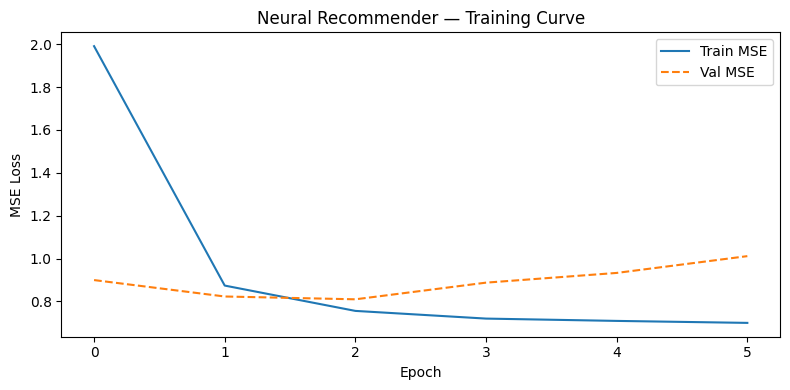


Neural recommender  RMSE: 0.9001
Traditional TF-IDF + cosine provides no direct RMSE (ranking only).
The neural model captures non-linear genre-rating interactions that TF-IDF cosine misses.


In [24]:
# ── Keras trains locally ────────────────────
nn_sample_pd = (
    train_ratings
    .join(movies.select("movieId","genres_clean","year","movie_avg_rating"),
          on="movieId", how="left")
    .limit(MAX_NEURAL_ROWS)
    .toPandas()
)

try:
    nn_sample_pd["genre_list"] = nn_sample_pd["genres_clean"].fillna("Unknown").str.split("|")
    all_genres  = sorted({g for lst in nn_sample_pd["genre_list"] for g in lst if g})
    genre_to_idx = {g: i for i, g in enumerate(all_genres)}

    def multi_hot(genres):
        vec = np.zeros(len(all_genres), dtype=np.float32)
        for g in genres:
            if g in genre_to_idx:
                vec[genre_to_idx[g]] = 1.0
        return vec

    nn_sample_pd["genre_vec"] = nn_sample_pd["genre_list"].apply(multi_hot)

    y_min, y_max = nn_sample_pd["year"].dropna().min(), nn_sample_pd["year"].dropna().max()
    nn_sample_pd["year"]          = nn_sample_pd["year"].fillna(y_min)
    nn_sample_pd["year_norm"]     = (nn_sample_pd["year"] - y_min) / (y_max - y_min + 1e-9)
    nn_sample_pd["avg_rating_norm"] = (nn_sample_pd["movie_avg_rating"] - 0.5) / 4.5

    X_movie = np.stack([
        np.concatenate([g, [y, a]])
        for g, y, a in zip(nn_sample_pd["genre_vec"],
                           nn_sample_pd["year_norm"],
                           nn_sample_pd["avg_rating_norm"])
    ]).astype(np.float32)

    user_avg_map_small = nn_sample_pd.groupby("userId")["rating"].mean().to_dict()
    X_user = np.array([[user_avg_map_small[u]] for u in nn_sample_pd["userId"]], dtype=np.float32)
    y_nn   = nn_sample_pd["rating"].astype(np.float32).values

    Xu_tr, Xu_val, Xm_tr, Xm_val, y_tr, y_val = train_test_split(
        X_user, X_movie, y_nn, test_size=0.2, random_state=42
    )

    # ── Two-branch network ────────────────────────────────────────────────────
    user_in  = Input(shape=(X_user.shape[1],),  name="user_input")
    u_emb    = Dense(16, activation="relu",      name="user_embedding")(user_in)

    movie_in = Input(shape=(X_movie.shape[1],), name="movie_input")
    m_emb    = Dense(64, activation="relu")(movie_in)
    m_emb    = Dense(32, activation="relu",      name="movie_embedding")(m_emb)

    x = Concatenate()([u_emb, m_emb])
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="linear", name="rating_output")(x)

    nn_model = Model(inputs=[user_in, movie_in], outputs=out)
    nn_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    nn_model.summary()

    history = nn_model.fit(
        [Xu_tr, Xm_tr], y_tr,
        validation_data=([Xu_val, Xm_val], y_val),
        epochs=20, batch_size=512, verbose=1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    )

    nn_val_pred = np.clip(nn_model.predict([Xu_val, Xm_val], verbose=0).ravel(), 0.5, 5.0)
    nn_rmse = rmse_score(y_val.tolist(), nn_val_pred.tolist())

    # ── Training curve ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history.history["loss"],     label="Train MSE")
    ax.plot(history.history["val_loss"], label="Val MSE",  linestyle="--")
    ax.set_title("Neural Recommender — Training Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); plt.tight_layout(); plt.show()

    print(f"\nNeural recommender  RMSE: {nn_rmse:.4f}")
    print(f"Traditional TF-IDF + cosine provides no direct RMSE (ranking only).")
    print("The neural model captures non-linear genre-rating interactions that TF-IDF cosine misses.")

except Exception as e:
    print("TensorFlow not available — neural section skipped:", e)
    nn_rmse = None

## Task 9: Reinforcement Learning in Recommender Systems

In [25]:
# ── Environment: top-200 popular movies as the arm space ──────────────────────
popular_movies_rl = [
    r["movieId"]
    for r in train_ratings.groupBy("movieId").count()
              .orderBy(F.desc("count")).limit(200).collect()
]

rl_pd = (
    ratings_raw
    .filter(F.col("movieId").isin(popular_movies_rl))
    .select("userId","movieId","rating")
    .limit(200000)
    .toPandas()
)

# Binary reward: 1 if rating ≥ 4, else 0, else 0 (no rating = neutral)
reward_table = {}
for row in rl_pd.itertuples(index=False):
    reward_table.setdefault(row.userId, {})[row.movieId] = (
        1 if row.rating >= POSITIVE_THRESHOLD else 0
    )

users_seq = list(rl_pd["userId"].drop_duplicates())[:500]
print(f"RL environment: {len(popular_movies_rl)} arms, {len(users_seq)} simulated users")

RL environment: 200 arms, 500 simulated users


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# ε-Greedy Bandit
# ═══════════════════════════════════════════════════════════════════════════════
class EpsilonGreedyBandit:
    """Recommend the highest-estimated-reward movie (1-ε), or explore randomly (ε)."""
    def __init__(self, arms, epsilon=0.1):
        self.arms    = list(arms)
        self.epsilon = epsilon
        self.counts  = {a: 0   for a in arms}
        self.values  = {a: 0.0 for a in arms}

    def choose(self):
        if random.random() < self.epsilon:
            return random.choice(self.arms)
        return max(self.arms, key=lambda a: self.values[a])

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]


# ═══════════════════════════════════════════════════════════════════════════════
# UCB Bandit
# ═══════════════════════════════════════════════════════════════════════════════
class UCBBandit:
    """
    Upper Confidence Bound: choose arm with highest (value + exploration bonus).
    Bonus = sqrt(2 * ln(total_pulls) / arm_pulls), so under-tried arms are
    prioritised — avoids the ε-Greedy drawback of random exploration.
    """
    def __init__(self, arms):
        self.arms   = list(arms)
        self.counts = {a: 0   for a in arms}
        self.values = {a: 0.0 for a in arms}
        self.total  = 0

    def choose(self):
        self.total += 1
        # Ensure every arm is tried at least once
        for a in self.arms:
            if self.counts[a] == 0:
                return a
        return max(
            self.arms,
            key=lambda a: self.values[a] + math.sqrt(2 * math.log(self.total) / self.counts[a])
        )

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]


# ═══════════════════════════════════════════════════════════════════════════════
# Q-Learning Agent
# ═══════════════════════════════════════════════════════════════════════════════
class QLearningAgent:
    """
    Simplified Q-Learning for recommendations.
    State  = discretised user preference (genre index the user has rated most).
    Action = movie (arm).
    Q-update: Q(s,a) ← Q(s,a) + α[r + γ·max_a Q(s',a') − Q(s,a)]
    """
    def __init__(self, states, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.states  = list(states)
        self.actions = list(actions)
        self.alpha   = alpha
        self.gamma   = gamma
        self.epsilon = epsilon
        # Q-table: state → {action: Q-value}
        self.Q = {s: {a: random.uniform(0, 0.1) for a in actions} for s in states}

    def get_state(self, user_id):
        """Map user to a coarse genre-preference state."""
        return user_id % len(self.states)   # deterministic bucketing

    def choose(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        q_row = self.Q[state]
        return max(q_row, key=q_row.get)

    def update(self, state, action, reward, next_state):
        best_next = max(self.Q[next_state].values())
        td_target = reward + self.gamma * best_next
        td_error  = td_target - self.Q[state][action]
        self.Q[state][action] += self.alpha * td_error


print("Bandit and Q-Learning classes defindd")

Bandit and Q-Learning classes defindd


e-Greedy   avg reward: 0.3580  (explore rate fixed at 10%)
UCB        avg reward: 0.1280  (explore count: 400)
Q-Learning avg reward: 0.2540  (50-action subset)


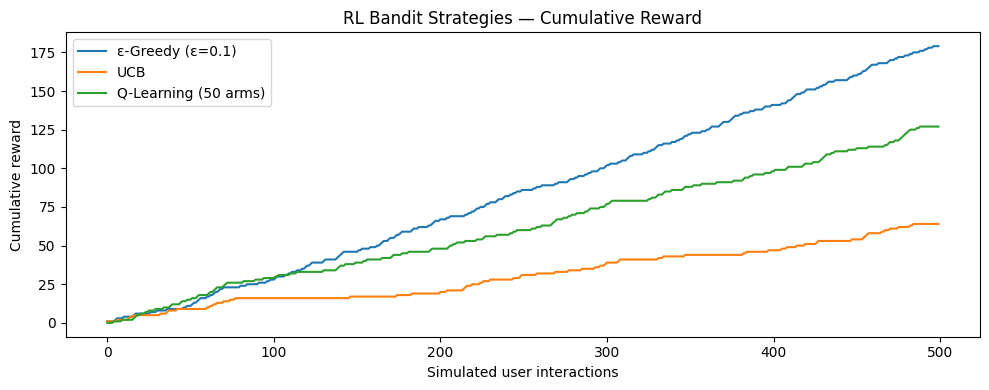

In [27]:
# ── Run e-Greedy ──────────────────────────────────────────────────────────────
eg      = EpsilonGreedyBandit(popular_movies_rl, epsilon=0.1)
eg_cum  = []; eg_total = 0

for uid in users_seq:
    arm    = eg.choose()
    reward = reward_table.get(uid, {}).get(arm, 0)
    eg.update(arm, reward)
    eg_total += reward
    eg_cum.append(eg_total)

# ── Run UCB ───────────────────────────────────────────────────────────────────
ucb     = UCBBandit(popular_movies_rl)
ucb_cum = []; ucb_total = 0; ucb_explore = 0

for uid in users_seq:
    arm    = ucb.choose()
    reward = reward_table.get(uid, {}).get(arm, 0)
    if ucb.counts[arm] <= 1:
        ucb_explore += 1
    ucb.update(arm, reward)
    ucb_total += reward
    ucb_cum.append(ucb_total)

# ── Run Q-Learning ────────────────────────────────────────────────────────────
NUM_STATES = 20
ql  = QLearningAgent(
    states=list(range(NUM_STATES)),
    actions=popular_movies_rl[:50],   # limit action space for speed
    alpha=0.1, gamma=0.9, epsilon=0.1
)
ql_cum = []; ql_total = 0

for uid in users_seq:
    state      = ql.get_state(uid)
    action     = ql.choose(state)
    reward     = reward_table.get(uid, {}).get(action, 0)
    next_state = (state + 1) % NUM_STATES
    ql.update(state, action, reward, next_state)
    ql_total  += reward
    ql_cum.append(ql_total)

# ── Print summary ─────────────────────────────────────────────────────────────
n = len(users_seq)
print(f"e-Greedy   avg reward: {eg_total/n:.4f}  (explore rate fixed at 10%)")
print(f"UCB        avg reward: {ucb_total/n:.4f}  (explore count: {ucb_explore})")
print(f"Q-Learning avg reward: {ql_total/n:.4f}  (50-action subset)")

# ── Cumulative reward curve ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eg_cum,  label="ε-Greedy (ε=0.1)")
ax.plot(ucb_cum, label="UCB")
ax.plot(ql_cum,  label="Q-Learning (50 arms)")
ax.set_xlabel("Simulated user interactions")
ax.set_ylabel("Cumulative reward")
ax.set_title("RL Bandit Strategies — Cumulative Reward")
ax.legend(); plt.tight_layout(); plt.show()

---
# Part 6: Explainability in Recommender Systems

## Task 10: Feature-Based Explanations (Content-Based Filtering)

=== SHAP Feature Importance (mean |SHAP value|) ===


,feature,mean_abs_shap
2,movie_avg_rating,0.284553
1,cf_score,0.267953
0,cbf_score,0.056832
3,user_avg_rating,0.047264


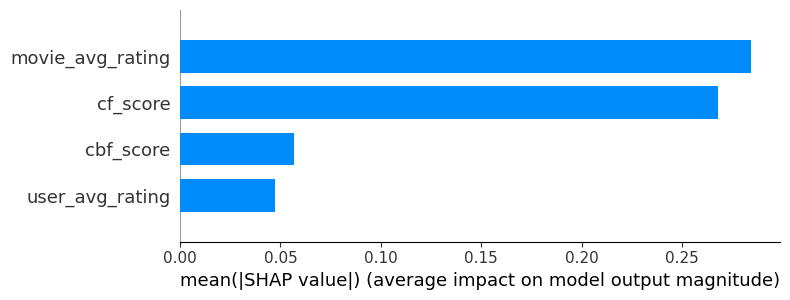

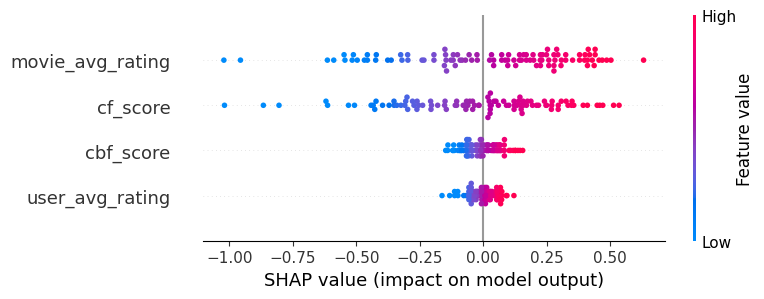


=== Explanation for userId=286, movie='Kill Bill: Vol. 2 (2004)' ===
  cbf_score                  value=0.624  SHAP=+0.0652 ↑
  cf_score                   value=3.779  SHAP=+0.0503 ↑
  movie_avg_rating           value=3.868  SHAP=+0.1702 ↑
  user_avg_rating            value=3.788  SHAP=+0.0280 ↑


In [28]:
try:
    # Using a small subsample for speed
    shap_sample = meta_test_df[META_FEATURES].head(200).reset_index(drop=True)

    explainer_shap  = shap.LinearExplainer(meta_model, meta_train_df[META_FEATURES])
    shap_values     = explainer_shap.shap_values(shap_sample)

    print("=== SHAP Feature Importance (mean |SHAP value|) ===")
    shap_importance = pd.DataFrame({
        "feature": META_FEATURES,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)
    display(shap_importance)

    # Summary bar plot
    shap.summary_plot(shap_values, shap_sample, plot_type="bar",
                      feature_names=META_FEATURES, show=True)

    # Detailed beeswarm for first 100 samples
    shap.summary_plot(shap_values[:100], shap_sample.head(100),
                      feature_names=META_FEATURES, show=True)

    # ── Single-prediction explanation ─────────────────────────────────────────
    idx = 0
    uid_ex  = int(meta_test_df.iloc[idx]["userId"])
    mid_ex  = int(meta_test_df.iloc[idx]["movieId"])
    mv_row  = movies_tfidf_local[movies_tfidf_local["movieId"] == mid_ex]
    mv_title = mv_row["title"].values[0] if not mv_row.empty else str(mid_ex)

    print(f"\n=== Explanation for userId={uid_ex}, movie='{mv_title}' ===")
    feat_vals = dict(zip(META_FEATURES, shap_sample.iloc[idx].values))
    shap_vals  = dict(zip(META_FEATURES, shap_values[idx]))
    for f in META_FEATURES:
        direction = "↑" if shap_vals[f] > 0 else "↓"
        print(f"  {f:25s}  value={feat_vals[f]:.3f}  SHAP={shap_vals[f]:+.4f} {direction}")

except ImportError:
    print("SHAP not installed. Run: pip install shap")

## Task 11: Neighbourhood-Based Explanations (Collaborative Filtering)

In [29]:
def explain_user_cf(user_id, movie_id, k=5):
    """
    Returns a human-readable explanation of why movie_id was recommended
    to user_id by User-CF, showing the top-k similar users who liked it.
    """
    if user_id not in ui_train.index or movie_id not in ui_train.columns:
        return "Cannot explain: user or movie not in training matrix."

    sims         = user_similarity.loc[user_id]
    movie_ratings = ui_train[movie_id]
    neighbors    = (
        pd.DataFrame({"sim": sims, "rating": movie_ratings})
        .dropna()
        .query("sim > 0")
        .sort_values("sim", ascending=False)
        .head(k)
    )

    if neighbors.empty:
        return "No similar users found — falling back to user mean."

    mv_row = movies_tfidf_local[movies_tfidf_local["movieId"] == movie_id]
    title  = mv_row["title"].values[0] if not mv_row.empty else str(movie_id)

    lines = [f"'{title}' was recommended to user {user_id} because:"]
    for nb_uid, nb_row in neighbors.iterrows():
        lines.append(f"  • User {nb_uid} (similarity={nb_row['sim']:.3f}) rated it {nb_row['rating']:.1f}/5")
    return "\n".join(lines)


def explain_item_cf(user_id, movie_id, k=5):
    """
    Explains an Item-CF recommendation by showing the most similar items
    the user has already rated highly.
    """
    if user_id not in ui_train.index or movie_id not in ui_train.columns:
        return "Cannot explain."

    user_ratings = ui_train.loc[user_id].dropna()
    sims         = item_similarity.loc[movie_id, user_ratings.index]
    neighbors    = (
        pd.DataFrame({"sim": sims, "rating": user_ratings})
        .query("sim > 0")
        .sort_values("sim", ascending=False)
        .head(k)
    )

    mv_row = movies_tfidf_local[movies_tfidf_local["movieId"] == movie_id]
    title  = mv_row["title"].values[0] if not mv_row.empty else str(movie_id)

    lines = [f"'{title}' was recommended because it also rated:"]
    for nb_mid, nb_row in neighbors.iterrows():
        nb_mv  = movies_tfidf_local[movies_tfidf_local["movieId"] == nb_mid]
        nb_ttl = nb_mv["title"].values[0] if not nb_mv.empty else str(nb_mid)
        lines.append(f"  • '{nb_ttl}' (item-sim={nb_row['sim']:.3f}, current rating={nb_row['rating']:.1f})")
    return "\n".join(lines)


# ── Demo ──────────────────────────────────────────────────────────────────────
sample_uid   = next((u for u in eval_users if u in ui_train.index), None)
sample_movie = list(ui_train.columns)[0]

if sample_uid:
    print(explain_user_cf(sample_uid, sample_movie, k=5))
    print()
    print(explain_item_cf(sample_uid, sample_movie, k=5))

'Toy Story (1995)' was recommended to user 414 because:
  • User 448 (similarity=0.261) rated it 5.0/5
  • User 249 (similarity=0.256) rated it 4.0/5
  • User 57 (similarity=0.252) rated it 5.0/5
  • User 590 (similarity=0.251) rated it 4.0/5
  • User 480 (similarity=0.242) rated it 3.0/5

'Toy Story (1995)' was recommended because it also rated:
  • 'Lion King, The (1994)' (item-sim=0.511, current rating=4.0)
  • 'Toy Story 2 (1999)' (item-sim=0.470, current rating=5.0)
  • 'Independence Day (a.k.a. ID4) (1996)' (item-sim=0.453, current rating=4.0)
  • 'Mission: Impossible (1996)' (item-sim=0.453, current rating=4.0)
  • 'Shrek (2001)' (item-sim=0.446, current rating=4.0)


## Task 12: Model-Agnostic Explainability — LIME for the Neural Recommender

LIME explanation for instance 0:
  3.69 < movie_avg_rating <= 3.95                weight=+0.2080  → pushes rating UP
  3.67 < cf_score <= 3.97                        weight=+0.1944  → pushes rating UP
  cbf_score > 0.59                               weight=+0.1139  → pushes rating UP
  3.55 < user_avg_rating <= 3.86                 weight=+0.0529  → pushes rating UP


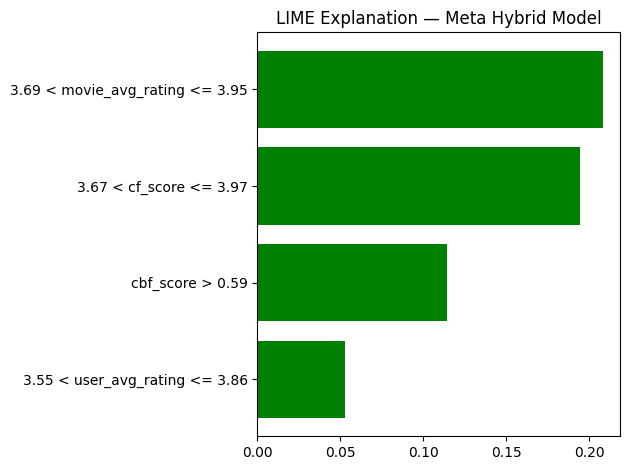

In [30]:
try:
    lime_train_data = meta_train_df[META_FEATURES].values
    lime_explainer  = lime.lime_tabular.LimeTabularExplainer(
        training_data  = lime_train_data,
        feature_names  = META_FEATURES,
        mode           = "regression",
        random_state   = 42,
    )

    # Wrap meta_model as a function for LIME
    def meta_predict(X):
        return np.clip(meta_model.predict(pd.DataFrame(X, columns=META_FEATURES)), 0.5, 5.0)

    # Explain the first test instance
    instance = meta_test_df[META_FEATURES].iloc[0].values
    lime_exp  = lime_explainer.explain_instance(
        data_row         = instance,
        predict_fn       = meta_predict,
        num_features     = len(META_FEATURES),
    )

    print("LIME explanation for instance 0:")
    for feat, weight in lime_exp.as_list():
        direction = "pushes rating UP" if weight > 0 else "pushes rating DOWN"
        print(f"  {feat:45s}  weight={weight:+.4f}  → {direction}")

    lime_exp.as_pyplot_figure()
    plt.title("LIME Explanation — Meta Hybrid Model")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("LIME not installed. Run: pip install lime")

<!-- ## Task 13: Evaluating Explainability

Here comparing the three explainability approaches qualitatively. -->

---
# Final Model Comparison and Summary

,Model,RMSE,Precision@5,Recall@5
0,Content TF-IDF (User Profile),NaN,0.0260,0.0022
1,User-CF (k=30),0.8267,0.3733,0.0242
2,Item-CF (k=20),0.8433,0.4333,0.0281
3,Manual SVD (k=40),0.8842,0.3333,0.0225
4,Spark ALS,0.8739,0.0060,0.0006
5,Meta-Learning Hybrid,0.8016,0.3500,0.0368
6,Neural Recommender,0.9001,NaN,NaN


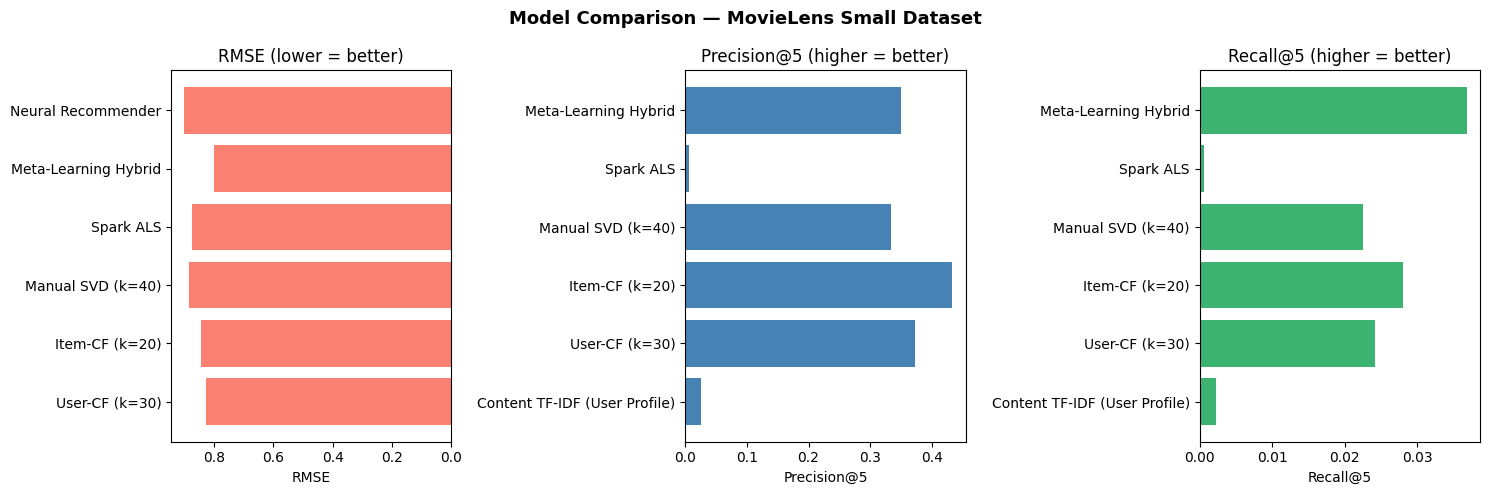

In [31]:
# ── Collect all RMSE / Precision@5 / Recall@5 ────────────────────────────────
best_ucf = user_cf_metrics_df.sort_values(["rmse","precision@5"], ascending=[True,False]).iloc[0]
best_icf = item_cf_metrics_df.sort_values(["rmse","precision@5"], ascending=[True,False]).iloc[0]

summary_rows = [
    {"Model": "Content TF-IDF (User Profile)",    "RMSE": None,           "Precision@5": content_p5,  "Recall@5": content_r5},
    {"Model": f"User-CF (k={int(best_ucf['k'])})", "RMSE": best_ucf["rmse"],"Precision@5": best_ucf["precision@5"], "Recall@5": best_ucf["recall@5"]},
    {"Model": f"Item-CF (k={int(best_icf['k'])})", "RMSE": best_icf["rmse"],"Precision@5": best_icf["precision@5"], "Recall@5": best_icf["recall@5"]},
    {"Model": f"Manual SVD (k={max_k})",           "RMSE": svd_rmse,       "Precision@5": svd_p5,      "Recall@5": svd_r5},
    {"Model": "Spark ALS",                         "RMSE": als_rmse,       "Precision@5": als_p5,      "Recall@5": als_r5},
    {"Model": "Meta-Learning Hybrid",              "RMSE": hybrid_meta_rmse,"Precision@5": hybrid_meta_p5,"Recall@5": hybrid_meta_r5},
]
if nn_rmse is not None:
    summary_rows.append({"Model": "Neural Recommender", "RMSE": nn_rmse, "Precision@5": None, "Recall@5": None})

comparison_df = pd.DataFrame(summary_rows)
display(comparison_df.round(4))

# ── Bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rmse_df = comparison_df.dropna(subset=["RMSE"])
axes[0].barh(rmse_df["Model"], rmse_df["RMSE"], color="salmon")
axes[0].set_title("RMSE (lower = better)"); axes[0].set_xlabel("RMSE")
axes[0].invert_xaxis()

p5_df = comparison_df.dropna(subset=["Precision@5"])
axes[1].barh(p5_df["Model"], p5_df["Precision@5"], color="steelblue")
axes[1].set_title("Precision@5 (higher = better)"); axes[1].set_xlabel("Precision@5")

r5_df = comparison_df.dropna(subset=["Recall@5"])
axes[2].barh(r5_df["Model"], r5_df["Recall@5"], color="mediumseagreen")
axes[2].set_title("Recall@5 (higher = better)"); axes[2].set_xlabel("Recall@5")

plt.suptitle("Model Comparison — MovieLens Small Dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()